# Project 1: David Copperfield Word Network Analysis

**Course**: INF322 - Social Network Analysis

**Instructor**: Katia Papakonstantinopoulou

---

## Overview

This notebook analyzes a network of commonly occurring adjectives and nouns from Charles Dickens' "David Copperfield". Nodes represent words, and edges connect words that appear adjacent in the text.

## 1. Setup and Imports

In [34]:
# Install required packages (run this cell first if packages are not installed)
# !pip install networkx pandas matplotlib seaborn python-louvain scipy

In [35]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import community.community_louvain as community_louvain
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# For better plots
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

## 2. Load Data

In [36]:
# Load nodes and edges
nodes_df = pd.read_csv('nodes.csv')
edges_df = pd.read_csv('edges.csv')

# Remove any rows with missing values
nodes_df = nodes_df.dropna()

# Convert id to int and label to string
nodes_df['id'] = nodes_df['id'].astype(int)
nodes_df['label'] = nodes_df['label'].astype(str)

print("Nodes:")
print(nodes_df.head(10))
print(f"\nTotal nodes: {len(nodes_df)}")

print("\nEdges:")
print(edges_df.head(10))
print(f"\nTotal edges: {len(edges_df)}")

Nodes:
   id      label
0   0  agreeable
1   1        man
2   2        old
3   3     person
4   4   anything
5   5      short
6   6        arm
7   7      round
8   8       aunt
9   9      first

Total nodes: 112

Edges:
   source  target        type
0       1       0  Undirected
1       2       0  Undirected
2       2       1  Undirected
3       3       0  Undirected
4       3       2  Undirected
5       5       4  Undirected
6       6       5  Undirected
7       7       6  Undirected
8       9       1  Undirected
9       9       2  Undirected

Total edges: 425


## 3. Create NetworkX Graph

In [37]:
# Create undirected graph
G = nx.Graph()

# Add nodes with labels
for _, row in nodes_df.iterrows():
    G.add_node(row['id'], label=row['label'])

# Add edges
for _, row in edges_df.iterrows():
    G.add_edge(row['source'], row['target'])

print(f"Graph created successfully!")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Is connected: {nx.is_connected(G)}")

if not nx.is_connected(G):
    print(f"Number of connected components: {nx.number_connected_components(G)}")

Graph created successfully!
Number of nodes: 112
Number of edges: 425
Is connected: True


## 4. Network Metrics Calculation

### 4.1 Degree Centrality

In [38]:
# Calculate degree for each node
degrees = dict(G.degree())

# Add degree as node attribute
nx.set_node_attributes(G, degrees, 'degree')

# Find nodes with max degree
max_degree = max(degrees.values())
max_degree_nodes = [node for node, deg in degrees.items() if deg == max_degree]

print(f"Maximum degree: {max_degree}")
print(f"Nodes with maximum degree:")
for node in max_degree_nodes:
    print(f"  - {G.nodes[node]['label']} (id={node}, degree={max_degree})")

# Show top 10 nodes by degree
top_degree_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 nodes by degree:")
for node, deg in top_degree_nodes:
    print(f"  {G.nodes[node]['label']:20s} - degree: {deg}")

Maximum degree: 49
Nodes with maximum degree:
  - little (id=17, degree=49)

Top 10 nodes by degree:
  little               - degree: 49
  old                  - degree: 33
  other                - degree: 28
  good                 - degree: 28
  same                 - degree: 21
  first                - degree: 17
  room                 - degree: 15
  way                  - degree: 15
  dear                 - degree: 15
  man                  - degree: 14


### 4.2 Network Diameter

In [39]:
# Calculate diameter
if nx.is_connected(G):
    diameter = nx.diameter(G)
    print(f"Network diameter: {diameter}")
else:
    # If not connected, calculate for largest component
    largest_cc = max(nx.connected_components(G), key=len)
    subgraph = G.subgraph(largest_cc)
    diameter = nx.diameter(subgraph)
    print(f"Network is not connected.")
    print(f"Diameter of largest connected component: {diameter}")

Network diameter: 5


### 4.3 Betweenness Centrality

In [40]:
# Calculate betweenness centrality
betweenness = nx.betweenness_centrality(G)

# Add as node attribute
nx.set_node_attributes(G, betweenness, 'betweenness')

# Find node with max betweenness
max_betweenness_node = max(betweenness.items(), key=lambda x: x[1])
node_id, max_bet_value = max_betweenness_node

print(f"Node with largest betweenness centrality:")
print(f"  Word: {G.nodes[node_id]['label']}")
print(f"  Node ID: {node_id}")
print(f"  Betweenness: {max_bet_value:.6f}")

# Top 10 by betweenness
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 nodes by betweenness centrality:")
for node, bet in top_betweenness:
    print(f"  {G.nodes[node]['label']:20s} - betweenness: {bet:.6f}")

Node with largest betweenness centrality:
  Word: little
  Node ID: 17
  Betweenness: 0.244685

Top 10 nodes by betweenness centrality:
  little               - betweenness: 0.244685
  old                  - betweenness: 0.128673
  other                - betweenness: 0.097456
  good                 - betweenness: 0.094879
  first                - betweenness: 0.070844
  whole                - betweenness: 0.053127
  same                 - betweenness: 0.049765
  way                  - betweenness: 0.043367
  man                  - betweenness: 0.036504
  better               - betweenness: 0.033892


### 4.4 PageRank

In [41]:
# Calculate PageRank
pagerank = nx.pagerank(G)

# Add as node attribute
nx.set_node_attributes(G, pagerank, 'pagerank')

# Top 10 by PageRank
top_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by PageRank:")
for node, pr in top_pagerank:
    print(f"  {G.nodes[node]['label']:20s} - PageRank: {pr:.6f}")

Top 10 nodes by PageRank:
  little               - PageRank: 0.050505
  old                  - PageRank: 0.035712
  other                - PageRank: 0.029403
  good                 - PageRank: 0.028915
  same                 - PageRank: 0.022004
  first                - PageRank: 0.020150
  whole                - PageRank: 0.016734
  way                  - PageRank: 0.016237
  man                  - PageRank: 0.016015
  room                 - PageRank: 0.015654


### 4.5 Community Detection (Louvain Algorithm)

In [42]:
# Detect communities using Louvain algorithm
communities = community_louvain.best_partition(G)

# Add community as node attribute
nx.set_node_attributes(G, communities, 'community')

# Count communities
num_communities = len(set(communities.values()))
print(f"Number of communities detected: {num_communities}")

# Community sizes
community_sizes = Counter(communities.values())
print("\nCommunity sizes:")
for comm_id, size in sorted(community_sizes.items()):
    print(f"  Community {comm_id}: {size} nodes")

Number of communities detected: 8

Community sizes:
  Community 0: 20 nodes
  Community 1: 8 nodes
  Community 2: 11 nodes
  Community 3: 16 nodes
  Community 4: 20 nodes
  Community 5: 17 nodes
  Community 6: 9 nodes
  Community 7: 11 nodes


### 4.6 Analyze Communities

Let's look at the words in each community to understand semantic groupings.

In [43]:
# Group nodes by community
community_nodes = {}
for node, comm in communities.items():
    if comm not in community_nodes:
        community_nodes[comm] = []
    community_nodes[comm].append(node)

# Display words in each community
print("Words in each community:\n")
for comm_id in sorted(community_nodes.keys()):
    nodes = community_nodes[comm_id]
    words = [G.nodes[node]['label'] for node in nodes]
    print(f"Community {comm_id} ({len(words)} words):")
    print(f"  {', '.join(sorted(words))}")
    print()

Words in each community:

Community 0 (20 words):
  agreeable, alone, bad, boy, child, dear, friend, late, man, miserable, money, mother, name, old, person, poor, pretty, woman, year, young

Community 1 (8 words):
  beautiful, black, happy, hard, letter, life, long, work

Community 2 (11 words):
  air, aunt, certain, day, early, first, lost, master, moment, morning, perfect

Community 3 (16 words):
  common, dark, face, kind, large, low, new, night, room, same, state, strange, thing, true, white, word

Community 4 (20 words):
  best, course, evening, family, light, love, manner, natural, other, place, pleasant, quiet, ready, short, side, time, usual, way, whole, world

Community 5 (17 words):
  arm, bed, bright, door, eye, fire, good, hand, home, hope, house, little, open, right, round, small, something

Community 6 (9 words):
  fancy, general, great, greater, head, part, red, strong, voice

Community 7 (11 words):
  anything, better, full, glad, half, heart, mind, nothing, possible, t

## 5. Ego Network Analysis

Select an interesting word and analyze its ego network at different depths.

In [44]:
# Select a word with moderate degree (not too central, not peripheral)
# Let's choose a word from the middle of the degree distribution

degree_list = sorted(degrees.items(), key=lambda x: x[1], reverse=True)
median_idx = len(degree_list) // 3  # Choose from upper-middle range

# You can manually select a word here
# For example, let's look for an interesting word around median degree
print("Suggested words for ego network analysis (moderate degree):")
for i in range(median_idx-5, median_idx+5):
    if i < len(degree_list):
        node, deg = degree_list[i]
        print(f"  {G.nodes[node]['label']:20s} - degree: {deg}, PageRank: {pagerank[node]:.6f}")

Suggested words for ego network analysis (moderate degree):
  person               - degree: 9, PageRank: 0.010604
  best                 - degree: 9, PageRank: 0.010060
  bright               - degree: 9, PageRank: 0.009957
  quiet                - degree: 9, PageRank: 0.009900
  part                 - degree: 8, PageRank: 0.009368
  certain              - degree: 8, PageRank: 0.009059
  light                - degree: 8, PageRank: 0.008954
  short                - degree: 7, PageRank: 0.008559
  air                  - degree: 7, PageRank: 0.009267
  woman                - degree: 7, PageRank: 0.008276


In [45]:
# CHOOSE YOUR WORD HERE
# Replace with the node ID of your chosen word
# For example, if you want to analyze the word "little" which has id=17:
selected_node = 17  # Change this based on your choice

selected_word = G.nodes[selected_node]['label']
selected_degree = G.degree(selected_node)
selected_pagerank = pagerank[selected_node]

print(f"Selected word: {selected_word}")
print(f"Degree: {selected_degree}")
print(f"PageRank: {selected_pagerank:.6f}")

Selected word: little
Degree: 49
PageRank: 0.050505


In [46]:
# Calculate ego networks at different depths
ego_depth_0 = {selected_node}  # Just the selected node
ego_depth_1 = set(G.neighbors(selected_node))  # Direct neighbors
ego_depth_2 = set()  # Neighbors of neighbors

for neighbor in ego_depth_1:
    ego_depth_2.update(G.neighbors(neighbor))

# Remove nodes already in depth 0 and 1
ego_depth_2 = ego_depth_2 - ego_depth_0 - ego_depth_1

# Remaining nodes
all_nodes = set(G.nodes())
ego_depth_3_plus = all_nodes - ego_depth_0 - ego_depth_1 - ego_depth_2

print(f"Ego network for '{selected_word}':")
print(f"  Depth 0 (selected node): {len(ego_depth_0)} node")
print(f"  Depth 1 (direct neighbors): {len(ego_depth_1)} nodes")
print(f"  Depth 2 (neighbors of neighbors): {len(ego_depth_2)} nodes")
print(f"  Depth 3+ (remaining): {len(ego_depth_3_plus)} nodes")

Ego network for 'little':
  Depth 0 (selected node): 1 node
  Depth 1 (direct neighbors): 49 nodes
  Depth 2 (neighbors of neighbors): 55 nodes
  Depth 3+ (remaining): 7 nodes


In [47]:
# Add ego_level attribute to all nodes
ego_levels = {}
for node in G.nodes():
    if node in ego_depth_0:
        ego_levels[node] = 0
    elif node in ego_depth_1:
        ego_levels[node] = 1
    elif node in ego_depth_2:
        ego_levels[node] = 2
    else:
        ego_levels[node] = 3

nx.set_node_attributes(G, ego_levels, 'ego_level')

# Show some words at each level
print(f"\nSample words at each ego level:")
print(f"\nDepth 0: {selected_word}")
print(f"\nDepth 1 neighbors:")
sample_d1 = list(ego_depth_1)[:10]
print(f"  {', '.join([G.nodes[n]['label'] for n in sample_d1])}")
print(f"\nDepth 2 neighbors:")
sample_d2 = list(ego_depth_2)[:10]
print(f"  {', '.join([G.nodes[n]['label'] for n in sample_d2])}")


Sample words at each ego level:

Depth 0: little

Depth 1 neighbors:
  man, old, short, round, first, boy, beautiful, black, face, friend

Depth 2 neighbors:
  agreeable, person, anything, arm, aunt, bad, air, letter, young, best


## 6. Visualizations

### 6.1 Degree Distribution

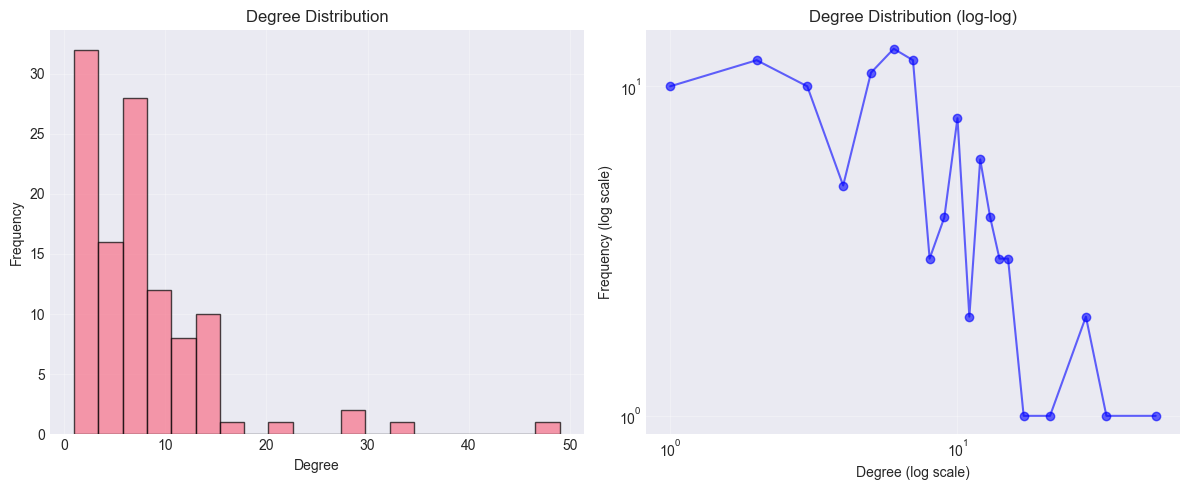

In [48]:
# Plot degree distribution
degree_values = list(degrees.values())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(degree_values, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Degree Distribution')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
degree_counts = Counter(degree_values)
degrees_sorted = sorted(degree_counts.items())
x = [d for d, c in degrees_sorted]
y = [c for d, c in degrees_sorted]
plt.loglog(x, y, 'bo-', alpha=0.6)
plt.xlabel('Degree (log scale)')
plt.ylabel('Frequency (log scale)')
plt.title('Degree Distribution (log-log)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('screenshots/degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Community Network Visualization

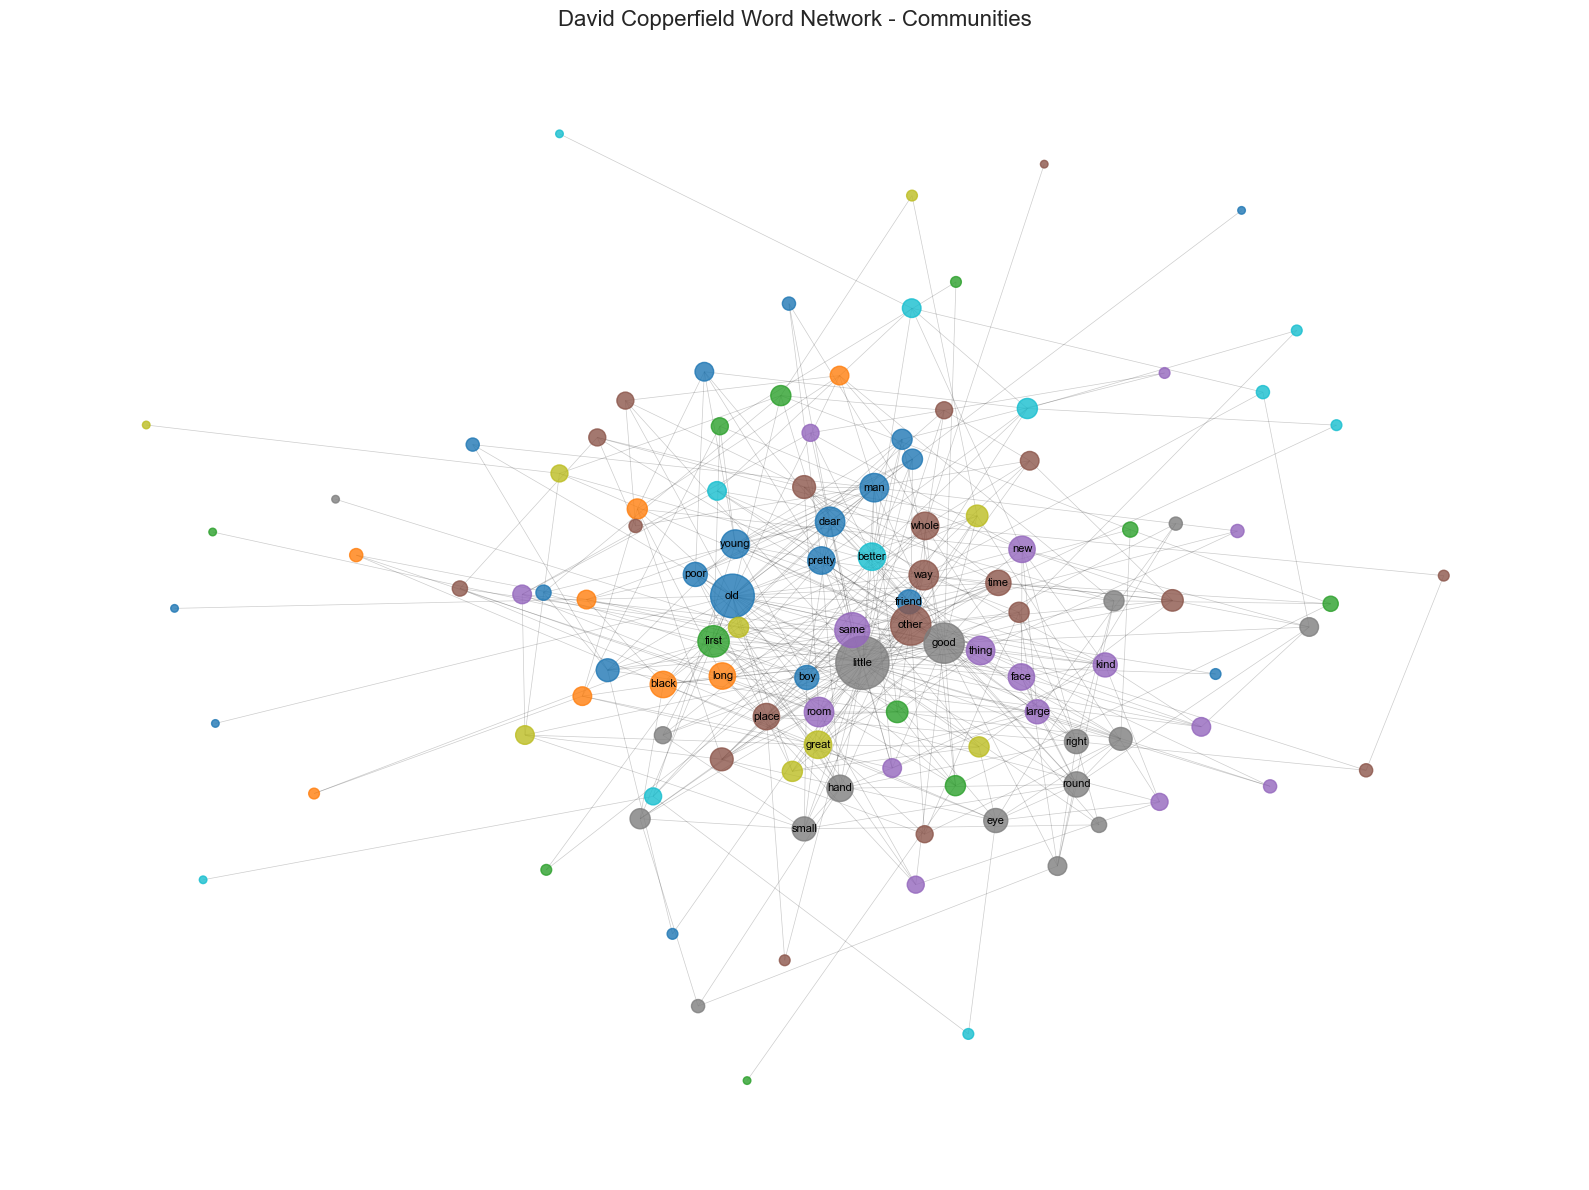

In [49]:
# Visualize network with communities
plt.figure(figsize=(16, 12))

# Use spring layout
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

# Node colors by community
node_colors = [communities[node] for node in G.nodes()]

# Node sizes by degree
node_sizes = [degrees[node] * 30 for node in G.nodes()]

# Draw network
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, 
                       alpha=0.8, cmap='tab10')
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)

# Draw labels for high-degree nodes only
high_degree_nodes = {node: G.nodes[node]['label'] for node in G.nodes() 
                     if degrees[node] >= np.percentile(degree_values, 75)}
nx.draw_networkx_labels(G, pos, labels=high_degree_nodes, font_size=8)

plt.title('David Copperfield Word Network - Communities', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig('screenshots/network_communities.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Ego Network Visualization

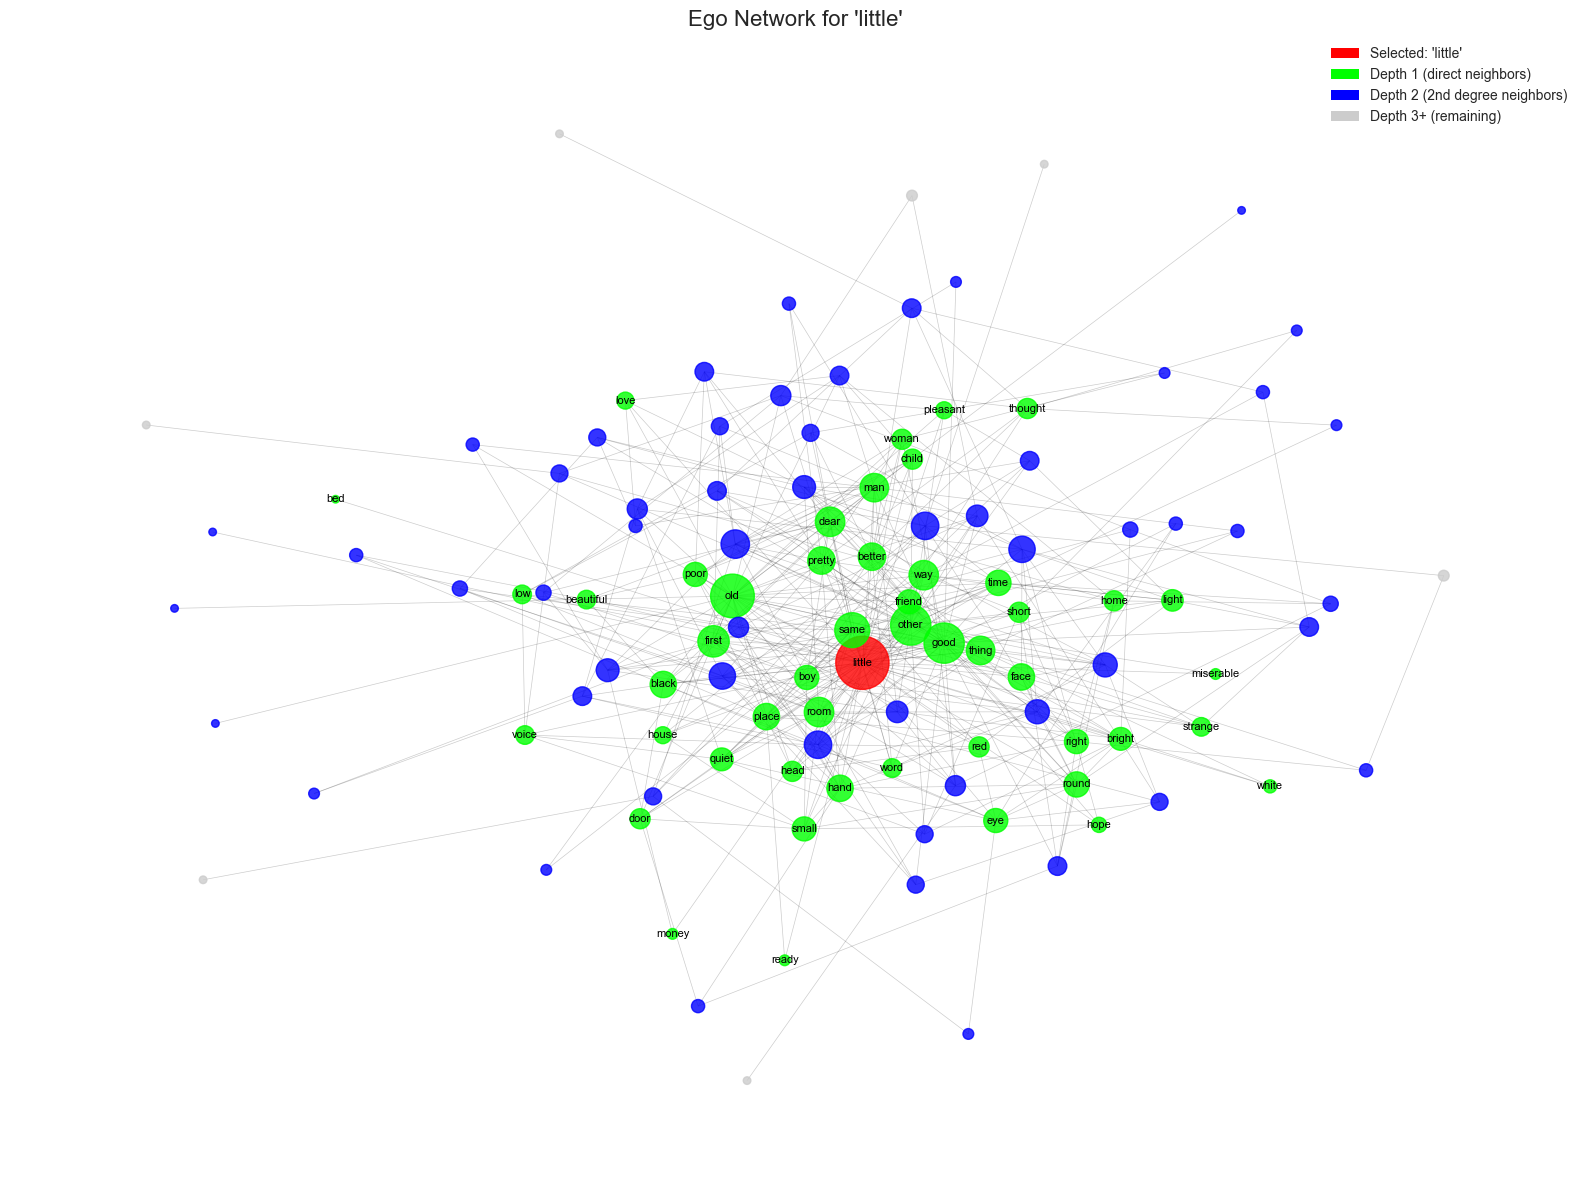

In [50]:
# Visualize ego network
plt.figure(figsize=(16, 12))

# Color map for ego levels
ego_colors = {0: '#ff0000', 1: '#00ff00', 2: '#0000ff', 3: '#cccccc'}
node_colors_ego = [ego_colors[ego_levels[node]] for node in G.nodes()]

# Node sizes by degree
node_sizes = [degrees[node] * 30 for node in G.nodes()]

# Draw network
nx.draw_networkx_nodes(G, pos, node_color=node_colors_ego, node_size=node_sizes, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)

# Draw labels for ego network nodes (depth 0, 1, 2)
ego_labels = {node: G.nodes[node]['label'] for node in G.nodes() 
              if ego_levels[node] <= 1}
nx.draw_networkx_labels(G, pos, labels=ego_labels, font_size=8)

# Create legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff0000', label=f"Selected: '{selected_word}'"),
    Patch(facecolor='#00ff00', label='Depth 1 (direct neighbors)'),
    Patch(facecolor='#0000ff', label='Depth 2 (2nd degree neighbors)'),
    Patch(facecolor='#cccccc', label='Depth 3+ (remaining)')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.title(f"Ego Network for '{selected_word}'", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig('screenshots/ego_network.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary Statistics

All the key statistics needed for the report.

In [51]:
print("="*60)
print("DAVID COPPERFIELD WORD NETWORK - SUMMARY STATISTICS")
print("="*60)

print("\n1. BASIC NETWORK PROPERTIES")
print(f"   Number of nodes: {G.number_of_nodes()}")
print(f"   Number of edges: {G.number_of_edges()}")
print(f"   Network diameter: {diameter}")
print(f"   Average degree: {sum(degrees.values()) / len(degrees):.2f}")

print("\n2. NODE WITH LARGEST BETWEENNESS CENTRALITY")
print(f"   Word: {G.nodes[node_id]['label']}")
print(f"   Betweenness: {max_bet_value:.6f}")

print("\n3. COMMUNITY DETECTION")
print(f"   Number of communities: {num_communities}")
print(f"   Community sizes: {dict(sorted(community_sizes.items()))}")

print("\n4. SELECTED WORD FOR EGO NETWORK")
print(f"   Word: {selected_word}")
print(f"   Degree: {selected_degree}")
print(f"   PageRank: {selected_pagerank:.6f}")
print(f"   Betweenness: {betweenness[selected_node]:.6f}")
print(f"   Community: {communities[selected_node]}")

print("\n5. TOP 5 NODES BY DEGREE")
for i, (node, deg) in enumerate(degree_list[:5], 1):
    print(f"   {i}. {G.nodes[node]['label']:20s} - degree: {deg}")

print("\n6. TOP 5 NODES BY BETWEENNESS")
for i, (node, bet) in enumerate(top_betweenness[:5], 1):
    print(f"   {i}. {G.nodes[node]['label']:20s} - betweenness: {bet:.6f}")

print("\n7. TOP 5 NODES BY PAGERANK")
for i, (node, pr) in enumerate(top_pagerank[:5], 1):
    print(f"   {i}. {G.nodes[node]['label']:20s} - PageRank: {pr:.6f}")

print("\n" + "="*60)

DAVID COPPERFIELD WORD NETWORK - SUMMARY STATISTICS

1. BASIC NETWORK PROPERTIES
   Number of nodes: 112
   Number of edges: 425
   Network diameter: 5
   Average degree: 7.59

2. NODE WITH LARGEST BETWEENNESS CENTRALITY
   Word: little
   Betweenness: 0.244685

3. COMMUNITY DETECTION
   Number of communities: 8
   Community sizes: {0: 20, 1: 8, 2: 11, 3: 16, 4: 20, 5: 17, 6: 9, 7: 11}

4. SELECTED WORD FOR EGO NETWORK
   Word: little
   Degree: 49
   PageRank: 0.050505
   Betweenness: 0.244685
   Community: 5

5. TOP 5 NODES BY DEGREE
   1. little               - degree: 49
   2. old                  - degree: 33
   3. other                - degree: 28
   4. good                 - degree: 28
   5. same                 - degree: 21

6. TOP 5 NODES BY BETWEENNESS
   1. little               - betweenness: 0.244685
   2. old                  - betweenness: 0.128673
   3. other                - betweenness: 0.097456
   4. good                 - betweenness: 0.094879
   5. first            

## 8. Export to GEXF for Gephi

In [52]:
# Export graph with all attributes to GEXF format
output_file = 'david_copperfield_network.gexf'
nx.write_gexf(G, output_file)

print(f"Graph exported successfully to: {output_file}")
print(f"\nNode attributes included:")
print(f"  - label: word text")
print(f"  - degree: node degree")
print(f"  - betweenness: betweenness centrality")
print(f"  - pagerank: PageRank value")
print(f"  - community: community ID")
print(f"  - ego_level: ego network depth (0, 1, 2, or 3)")
print(f"\nYou can now import this file into Gephi!")

Graph exported successfully to: david_copperfield_network.gexf

Node attributes included:
  - label: word text
  - degree: node degree
  - betweenness: betweenness centrality
  - pagerank: PageRank value
  - community: community ID
  - ego_level: ego network depth (0, 1, 2, or 3)

You can now import this file into Gephi!


## 9. Analysis Notes for Report

### Community Observations

Look at the community groupings above and note:
- Which words appear in the same community?
- Are there semantically different words grouped together?
- Why might they be in the same community? (Think about co-occurrence patterns in the text)

### Example observations to include in report:
1. Words that co-occur frequently in the text get grouped together
2. Some communities might represent character descriptions
3. Some communities might represent settings or emotions
4. Words with different meanings but similar usage patterns cluster together
